In [ ]:
import numpy as np
import random
import math
import time
import os
import matplotlib.cm as cm
import pandas as pd
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.notebook import tqdm
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Load battery data
Battery_list = ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
Battery = np.load('datasets/CALCE/CALCE.npy', allow_pickle=True)
Battery = Battery.item()

# Select first battery for this example
test_battery_name = 'CS2_35'
df_result = Battery[test_battery_name]
print(f"Loaded battery: {test_battery_name}")
print(f"Data shape: {df_result.shape}")
print(f"Columns: {df_result.columns.tolist()}")

Loaded battery: CS2_35
Data shape: (882, 6)
Columns: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']


In [ ]:
# Inspect available columns in the dataset
print("="*70)
print("DATASET COLUMN INSPECTION")
print("="*70)

for battery_name in Battery_list:
    df = Battery[battery_name]
    print(f"\n{battery_name} columns ({len(df.columns)}):")
    print(df.columns.tolist())
    print(f"Data types:\n{df.dtypes}")
    
    # Search for any voltage/current/temperature related columns
    all_cols_lower = [c.lower() for c in df.columns]
    has_voltage = any('voltage' in c or 'volt' in c or 'v_' in c for c in all_cols_lower)
    has_current = any('current' in c or 'curr' in c or 'i_' in c for c in all_cols_lower)
    has_temp = any('temperature' in c or 'temp' in c or 't_' in c for c in all_cols_lower)
    
    print(f"\nColumn search results:")
    print(f"  Contains voltage-like columns: {has_voltage}")
    print(f"  Contains current-like columns: {has_current}")
    print(f"  Contains temperature-like columns: {has_temp}")

DATASET COLUMN INSPECTION

CS2_35 columns (6):
['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']
Data types:
cycle         float64
capacity      float64
SoH           float64
resistance    float64
CCCT          float64
CVCT          float64
dtype: object

Column search results:
  Contains voltage-like columns: False
  Contains current-like columns: False
  Contains temperature-like columns: False

CS2_36 columns (6):
['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']
Data types:
cycle         float64
capacity      float64
SoH           float64
resistance    float64
CCCT          float64
CVCT          float64
dtype: object

Column search results:
  Contains voltage-like columns: False
  Contains current-like columns: False
  Contains temperature-like columns: False

CS2_37 columns (6):
['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']
Data types:
cycle         float64
capacity      float64
SoH           float64
resistance    float64
CCCT          float64
CVCT  

In [ ]:
# Deep inspection: Check NASA .mat files for additional features
import scipy.io as sio

print("\n" + "="*70)
print("NASA DATASET INSPECTION (.mat files)")
print("="*70)

nasa_files = {
    'B0005': 'datasets/NASA/B0005.mat',
    'B0006': 'datasets/NASA/B0006.mat',
    'B0007': 'datasets/NASA/B0007.mat',
    'B0018': 'datasets/NASA/B0018.mat'
}

for battery_id, filepath in nasa_files.items():
    try:
        mat_data = sio.loadmat(filepath)
        print(f"\n{battery_id}.mat keys:")
        # Filter out metadata keys (those starting with __)
        keys = [k for k in mat_data.keys() if not k.startswith('__')]
        for key in keys:
            data = mat_data[key]
            if isinstance(data, dict):
                print(f"  {key}: dict with keys {list(data.keys())}")
            elif isinstance(data, (list, tuple)):
                print(f"  {key}: list/tuple with {len(data)} elements")
            elif hasattr(data, 'shape'):
                print(f"  {key}: array with shape {data.shape}")
            else:
                print(f"  {key}: {type(data)}")
    except FileNotFoundError:
        print(f"\n{battery_id}.mat: FILE NOT FOUND")
    except Exception as e:
        print(f"\n{battery_id}.mat: ERROR - {e}")

print("\n" + "="*70)
print("FEATURE COMPARISON")
print("="*70)
print("\nCALCE Dataset Features:")
print("  Available: cycle, capacity, SoH, resistance, CCCT, CVCT")
print("  Missing: charge_capacity, discharge_capacity, charge_energy, discharge_energy")

print("\nCharging/Discharging Metrics:")
print("  CCCT: Constant Current Charge Time (how long to charge at constant current)")
print("  CVCT: Constant Voltage Charge Time (how long to charge at constant voltage)")
print("  These are TIME metrics, not ENERGY/CAPACITY metrics")

print("\nTo get charge/discharge capacity and energy, you would need:")
print("  - Raw NASA .mat files with cycle-by-cycle detailed measurements")
print("  - Extract feature engineering from raw voltage/current/temperature data")
print("  - Calculate integrated charge/discharge quantities from raw profiles")


NASA DATASET INSPECTION (.mat files)

B0005.mat keys:
  B0005: array with shape (1, 1)

B0006.mat keys:
  B0006: array with shape (1, 1)

B0007.mat keys:
  B0007: array with shape (1, 1)

B0018.mat keys:
  B0018: array with shape (1, 1)

FEATURE COMPARISON

CALCE Dataset Features:
  Available: cycle, capacity, SoH, resistance, CCCT, CVCT
  Missing: charge_capacity, discharge_capacity, charge_energy, discharge_energy

Charging/Discharging Metrics:
  CCCT: Constant Current Charge Time (how long to charge at constant current)
  CVCT: Constant Voltage Charge Time (how long to charge at constant voltage)
  These are TIME metrics, not ENERGY/CAPACITY metrics

To get charge/discharge capacity and energy, you would need:
  - Raw NASA .mat files with cycle-by-cycle detailed measurements
  - Extract feature engineering from raw voltage/current/temperature data
  - Calculate integrated charge/discharge quantities from raw profiles


In [ ]:
# Deep dive into NASA .mat file structure
print("\n" + "="*70)
print("DETAILED NASA .mat FILE STRUCTURE")
print("="*70)

try:
    mat_data = sio.loadmat('datasets/NASA/B0005.mat')
    b0005_data = mat_data['B0005'][0, 0]
    
    print("\nB0005.mat structure (nested object):")
    print(f"Type: {type(b0005_data)}")
    
    if hasattr(b0005_data, 'dtype'):
        print(f"\nFields available in B0005 structure:")
        for field_name in b0005_data.dtype.names:
            field_data = b0005_data[field_name]
            print(f"  {field_name}: shape={field_data.shape}, dtype={field_data.dtype}")
            
            # Show first level of nested data
            if field_data.shape[0] > 0 and hasattr(field_data[0, 0], 'dtype'):
                nested_obj = field_data[0, 0]
                if hasattr(nested_obj, 'dtype'):
                    print(f"    └─ Nested fields: {list(nested_obj.dtype.names)}")
                    
except Exception as e:
    print(f"Error exploring NASA data: {e}")
    import traceback
    traceback.print_exc()


DETAILED NASA .mat FILE STRUCTURE

B0005.mat structure (nested object):
Type: <class 'numpy.void'>

Fields available in B0005 structure:
  cycle: shape=(1, 616), dtype=[('type', 'O'), ('ambient_temperature', 'O'), ('time', 'O'), ('data', 'O')]
    └─ Nested fields: ['type', 'ambient_temperature', 'time', 'data']


In [ ]:
# Helper functions (aligned with Transformer notebook)
def build_sequences(text, window_size):
    """Convert 1D array into sliding window sequences."""
    x, y = [], []
    for i in range(len(text) - window_size):
        sequence = text[i:i + window_size]
        target = text[i + window_size]
        x.append(sequence)
        y.append(target)
    return np.array(x), np.array(y)

def build_sequences_multivariate(df, feature_cols, target_col, window_size):
    """Build multivariate sliding windows with a single-step target."""
    values_x = df[feature_cols].values.astype(np.float32)
    values_y = df[target_col].values.astype(np.float32)

    x, y = [], []
    for i in range(len(df) - window_size):
        x.append(values_x[i:i + window_size])
        y.append(values_y[i + window_size])

    return np.array(x, dtype=np.float32), np.array(y, dtype=np.float32)

def select_input_features(df, target_col='SoH', require_core_signals=False):
    """Select multivariate inputs and prefer voltage/current/temperature when available."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    candidate_cols = [c for c in numeric_cols if c != target_col]

    core_aliases = {
        'voltage': ['voltage', 'volt', 'v_'],
        'current': ['current', 'curr', 'i_'],
        'temperature': ['temperature', 'temp', 't_']
    }

    core_found = []
    missing_core = []

    for signal_name, aliases in core_aliases.items():
        matched = [c for c in candidate_cols if any(a in c.lower() for a in aliases)]
        if len(matched) == 0:
            missing_core.append(signal_name)
        else:
            core_found.extend(matched)

    if require_core_signals and len(missing_core) > 0:
        raise ValueError(
            f"Missing required core input signals: {missing_core}. "
            f"Available numeric columns: {numeric_cols}"
        )

    useful_aliases = ['cycle', 'resistance', 'ir', 'capacity', 'ccct', 'cvct', 'dqdv', 'energy', 'power']
    useful_cols = [
        c for c in candidate_cols
        if c not in core_found and any(a in c.lower() for a in useful_aliases)
    ]

    remaining_cols = [c for c in candidate_cols if c not in core_found and c not in useful_cols]
    feature_cols = core_found + useful_cols + remaining_cols
    return feature_cols, core_found, missing_core

def setup_seed(seed):
    """Set random seeds for reproducibility."""
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


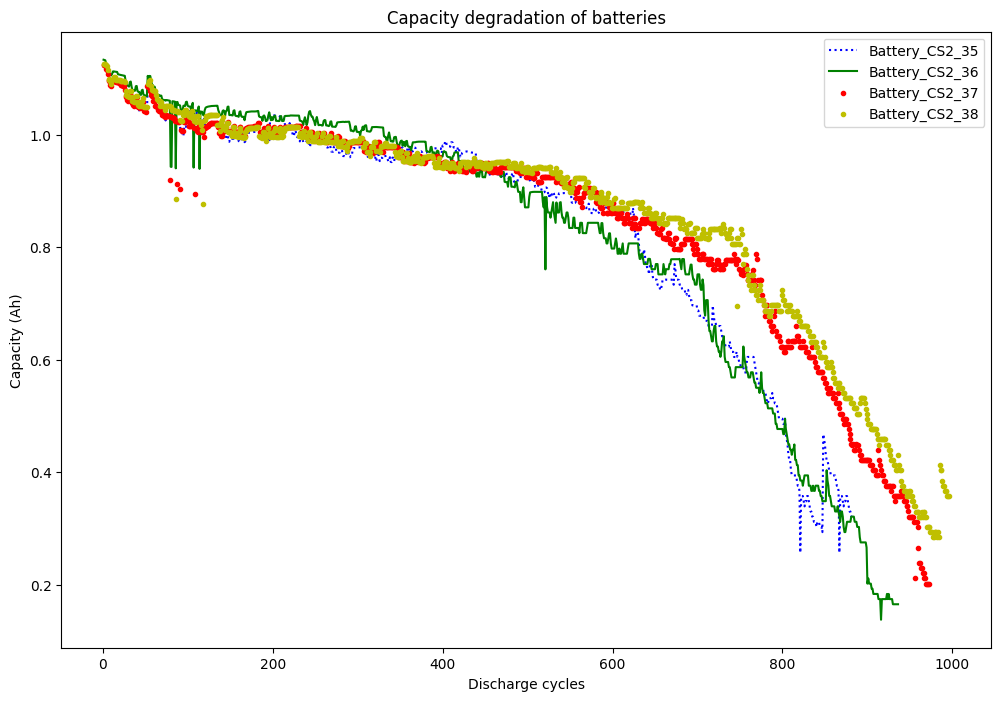

In [ ]:
# Visualize capacity degradation for all batteries
fig, ax = plt.subplots(1, figsize=(12, 8))
color_list = ['b:', 'g', 'r.', 'y.']
for name, color in zip(Battery_list, color_list):
    df_battery = Battery[name]
    ax.plot(df_battery['cycle'], df_battery['capacity'], color, label='Battery_' + name)
ax.set(xlabel='Discharge cycles', ylabel='Capacity (Ah)', title='Capacity degradation of batteries')
plt.legend()
plt.show()

DATA PREPROCESSING AND EXPLORATION

Common numeric columns across all batteries (6):
['CCCT', 'CVCT', 'SoH', 'capacity', 'cycle', 'resistance']

DATA SHAPE AND MISSING VALUES

CS2_35:
  Shape: (882, 6)
  Missing values: 18
  Columns: 6

CS2_36:
  Shape: (936, 6)
  Missing values: 13
  Columns: 6

CS2_37:
  Shape: (972, 6)
  Missing values: 14
  Columns: 6

CS2_38:
  Shape: (996, 6)
  Missing values: 10
  Columns: 6

FEATURE SELECTION

Selected features (5):
  Core signals found: []
  Core signals missing: ['voltage', 'current', 'temperature']
  All features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']

FEATURE STATISTICS (RAW DATA)

First 15 rows of feature statistics:
Battery    Feature        Mean         Std        Min         Max  Count
 CS2_35       CCCT 4740.616688 1462.542909   0.000000 6629.211049    864
 CS2_35       CVCT 2541.875751  506.611904   0.000000 3659.124675    864
 CS2_35   capacity    0.857863    0.205362   0.256677    1.126385    864
 CS2_35      cycle  43

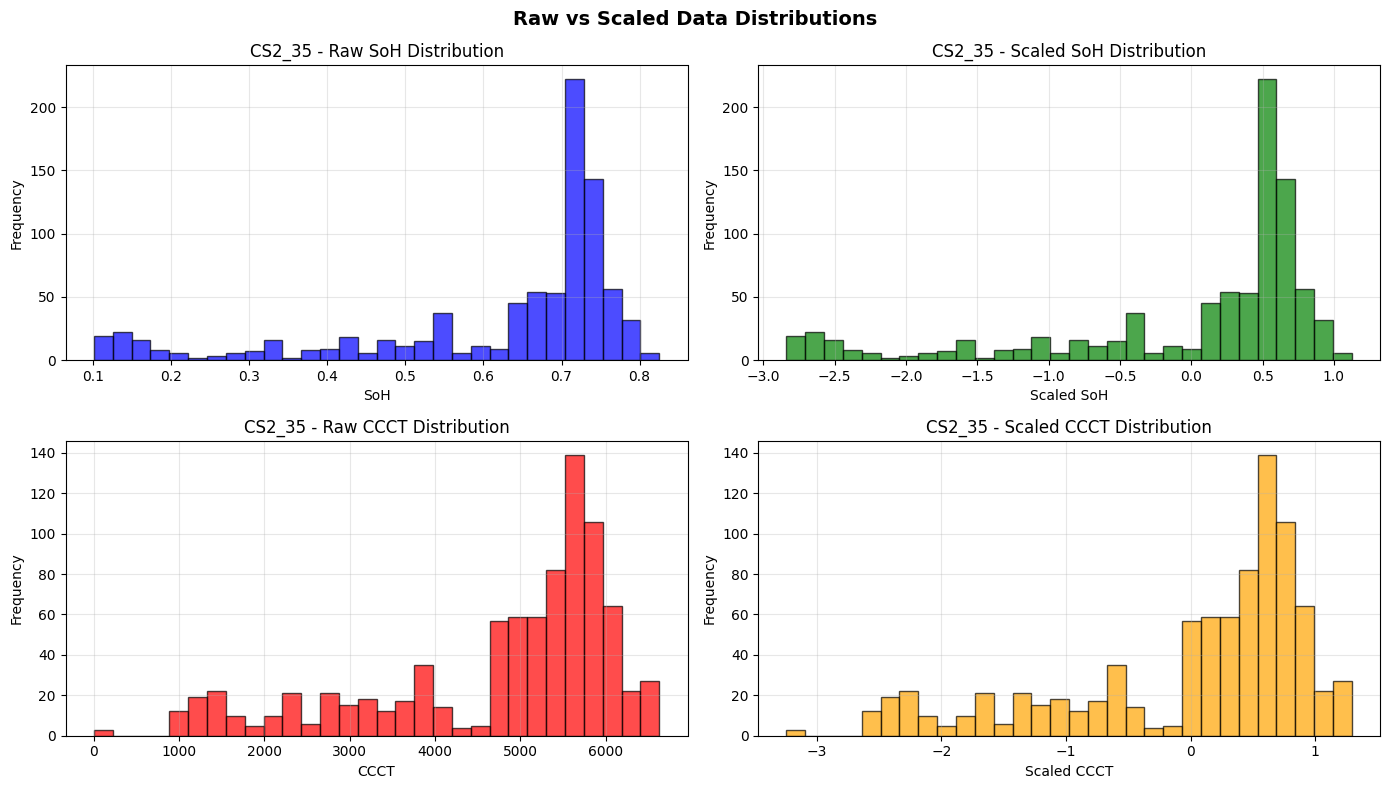


PREPROCESSING COMPLETE

Ready for model training with:
  - 4 batteries: ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
  - 5 input features
  - Target variable: SoH


In [ ]:
# Preprocessing and Exploratory Data Analysis
print("="*70)
print("DATA PREPROCESSING AND EXPLORATION")
print("="*70)

# 1. Identify common numeric columns across all batteries
common_numeric_cols = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

print(f"\nCommon numeric columns across all batteries ({len(common_numeric_cols)}):")
print(common_numeric_cols)

# 2. Explore data shape and missing values
print("\n" + "="*70)
print("DATA SHAPE AND MISSING VALUES")
print("="*70)

for battery_name in Battery_list:
    df = Battery[battery_name]
    print(f"\n{battery_name}:")
    print(f"  Shape: {df.shape}")
    print(f"  Missing values: {df.isnull().sum().sum()}")
    print(f"  Columns: {len(df.columns)}")

# 3. Select features for modeling
print("\n" + "="*70)
print("FEATURE SELECTION")
print("="*70)

feature_cols_prep, core_signals_prep, missing_signals_prep = select_input_features(
    Battery[Battery_list[0]][common_numeric_cols],
    target_col='SoH',
    require_core_signals=False
)

print(f"\nSelected features ({len(feature_cols_prep)}):")
print(f"  Core signals found: {core_signals_prep}")
if missing_signals_prep:
    print(f"  Core signals missing: {missing_signals_prep}")
print(f"  All features: {feature_cols_prep}")

# 4. Collect and display statistics for selected features
print("\n" + "="*70)
print("FEATURE STATISTICS (RAW DATA)")
print("="*70)

stats_rows = []
for battery_name in Battery_list:
    df = Battery[battery_name][feature_cols_prep + ['SoH']].dropna()
    for col in feature_cols_prep + ['SoH']:
        if col in df.columns:
            stats_rows.append({
                'Battery': battery_name,
                'Feature': col,
                'Mean': df[col].mean(),
                'Std': df[col].std(),
                'Min': df[col].min(),
                'Max': df[col].max(),
                'Count': len(df)
            })

stats_df = pd.DataFrame(stats_rows)
print("\nFirst 15 rows of feature statistics:")
print(stats_df.head(15).to_string(index=False))

# 5. Show data distribution before and after scaling
print("\n" + "="*70)
print("SCALING DEMONSTRATION (First Battery)")
print("="*70)

demo_battery = Battery_list[0]
df_demo = Battery[demo_battery][feature_cols_prep + ['SoH']].dropna().copy()

print(f"\nRaw data statistics for {demo_battery}:")
print(f"  SoH - Mean: {df_demo['SoH'].mean():.6f}, Std: {df_demo['SoH'].std():.6f}, Range: [{df_demo['SoH'].min():.6f}, {df_demo['SoH'].max():.6f}]")
print(f"  {feature_cols_prep[0]} - Mean: {df_demo[feature_cols_prep[0]].mean():.6f}, Std: {df_demo[feature_cols_prep[0]].std():.6f}")

# Demonstrate scaling
scaler_X_demo = StandardScaler()
scaler_y_demo = StandardScaler()

X_demo = df_demo[feature_cols_prep].values.astype(np.float32)
y_demo = df_demo['SoH'].values.astype(np.float32)

X_demo_scaled = scaler_X_demo.fit_transform(X_demo)
y_demo_scaled = scaler_y_demo.fit_transform(y_demo.reshape(-1, 1)).ravel()

print(f"\nScaled data statistics for {demo_battery}:")
print(f"  SoH - Mean: {y_demo_scaled.mean():.6f}, Std: {y_demo_scaled.std():.6f}, Range: [{y_demo_scaled.min():.6f}, {y_demo_scaled.max():.6f}]")
print(f"  {feature_cols_prep[0]} - Mean: {X_demo_scaled[:, 0].mean():.6f}, Std: {X_demo_scaled[:, 0].std():.6f}")

# 6. Visualize raw vs scaled distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Raw SoH
axes[0, 0].hist(df_demo['SoH'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title(f'{demo_battery} - Raw SoH Distribution')
axes[0, 0].set_xlabel('SoH')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Scaled SoH
axes[0, 1].hist(y_demo_scaled, bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_title(f'{demo_battery} - Scaled SoH Distribution')
axes[0, 1].set_xlabel('Scaled SoH')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Raw feature
axes[1, 0].hist(df_demo[feature_cols_prep[0]], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1, 0].set_title(f'{demo_battery} - Raw {feature_cols_prep[0]} Distribution')
axes[1, 0].set_xlabel(feature_cols_prep[0])
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Scaled feature
axes[1, 1].hist(X_demo_scaled[:, 0], bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].set_title(f'{demo_battery} - Scaled {feature_cols_prep[0]} Distribution')
axes[1, 1].set_xlabel(f'Scaled {feature_cols_prep[0]}')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Raw vs Scaled Data Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PREPROCESSING COMPLETE")
print("="*70)
print(f"\nReady for model training with:")
print(f"  - {len(Battery_list)} batteries: {Battery_list}")
print(f"  - {len(feature_cols_prep)} input features")
print(f"  - Target variable: SoH")

In [ ]:
# Shared settings (aligned with Transformer notebook)
setup_seed(42)

window_size = 16
batch_size = 32
target_col = 'SoH'

cv_window_size = 16
cv_batch_size = 32
cv_max_epochs = 180
cv_patience = 20

print(f"Window size: {window_size}")
print(f"Target column: {target_col}")

Window size: 16
Target column: SoH


In [ ]:
# CNN model definition (adapted from DNN to use 1D convolutions)
class CNN_SOHPredictor(nn.Module):
    """CNN that consumes [batch, window, features] and predicts next-step SoH."""
    def __init__(self, window_size, input_dim, out_channels=[32, 64, 128], kernel_size=3, dropout_rate=0.3):
        super().__init__()
        
        # 1D convolutional layers
        padding = kernel_size // 2
        conv_layers = []
        in_channels = 1
        
        for out_ch in out_channels:
            conv_layers.append(nn.Conv1d(in_channels, out_ch, kernel_size=kernel_size, padding=padding))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
            if dropout_rate > 0:
                conv_layers.append(nn.Dropout(dropout_rate))
            in_channels = out_ch
        
        self.conv_net = nn.Sequential(*conv_layers)
        
        # Calculate the flattened size after convolutions
        with torch.no_grad():
            test_input = torch.randn(1, 1, window_size * input_dim)
            test_output = self.conv_net(test_input)
            flattened_size = test_output.view(1, -1).size(1)
        
        # Fully connected layers
        fc_layers = []
        fc_in = flattened_size
        fc_layers.append(nn.Linear(fc_in, 128))
        fc_layers.append(nn.ReLU())
        if dropout_rate > 0:
            fc_layers.append(nn.Dropout(dropout_rate))
        fc_layers.append(nn.Linear(128, 64))
        fc_layers.append(nn.ReLU())
        if dropout_rate > 0:
            fc_layers.append(nn.Dropout(dropout_rate))
        fc_layers.append(nn.Linear(64, 1))
        
        self.fc_net = nn.Sequential(*fc_layers)

    def forward(self, x):
        # x shape: [batch, window, features]
        batch_size, window, features = x.shape
        # Reshape to [batch, 1, window*features] for Conv1d
        x = x.reshape(batch_size, 1, -1)
        x = self.conv_net(x)
        x = x.view(batch_size, -1)
        x = self.fc_net(x)
        return x

# Preview with placeholder feature count; real model is created in training cells
preview_input_dim = 8
cnn_preview = CNN_SOHPredictor(window_size=window_size, input_dim=preview_input_dim).to(device)
print(cnn_preview)
print(f"CNN parameters (preview, input_dim={preview_input_dim}): {sum(p.numel() for p in cnn_preview.parameters()):,}")

CNN_SOHPredictor(
  (conv_net): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): ReLU()
    (10): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.3, inplace=False)
  )
  (fc_net): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
CNN

In [ ]:
# Training utilities (same training behavior as Transformer notebook)
def eval_loader_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    preds_all, targets_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb).squeeze(-1)
            loss = criterion(pred, yb)
            running_loss += loss.item() * xb.size(0)
            preds_all.append(pred.cpu().numpy())
            targets_all.append(yb.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    return avg_loss, np.concatenate(preds_all), np.concatenate(targets_all)

Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features used as input: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
Target used as output: SoH
Train batteries: ['CS2_35', 'CS2_36', 'CS2_38']
Validation split source: ['CS2_35', 'CS2_36', 'CS2_38']
Test battery: CS2_35
Future prediction battery (excluded from train/val/test): CS2_37
Train/Val/Test samples: 2316/409/848
Future battery samples: 942
Late-life weighting: threshold SoH<0.6, extra weight=1.5
CNN model parameters: 203,329
Epoch   1/300 | Train: 1.372864 | Val: 0.539349 | LR: 0.000500
Epoch  20/300 | Train: 0.398656 | Val: 0.103400 | LR: 0.000500
Epoch  40/300 | Train: 0.352673 | Val: 0.088743 | LR: 0.000125
Early stopping at epoch 42 (best val loss: 0.050596)

CNN Test RMSE: 0.016085
CNN Test MAE : 0.010020


Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features used as input: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
Target used as output: SoH
Train batteries: ['CS2_35', 'CS2_36', 'CS2_38']
Validation split source: ['CS2_35', 'CS2_36', 'CS2_38']
Test battery: CS2_35
Future prediction battery (excluded from train/val/test): CS2_37
Train/Val/Test samples: 2316/409/848
Future battery samples: 942
Late-life weighting: threshold SoH<0.6, extra weight=1.5
CNN model parameters: 203,329
Epoch   1/300 | Train: 1.372864 | Val: 0.539349 | LR: 0.000500
Epoch  20/300 | Train: 0.398656 | Val: 0.103400 | LR: 0.000500
Epoch  40/300 | Train: 0.352673 | Val: 0.088743 | LR: 0.000125
Early stopping at epoch 42 (best val loss: 0.050596)

CNN Test RMSE: 0.016085
CNN Test MAE : 0.010020


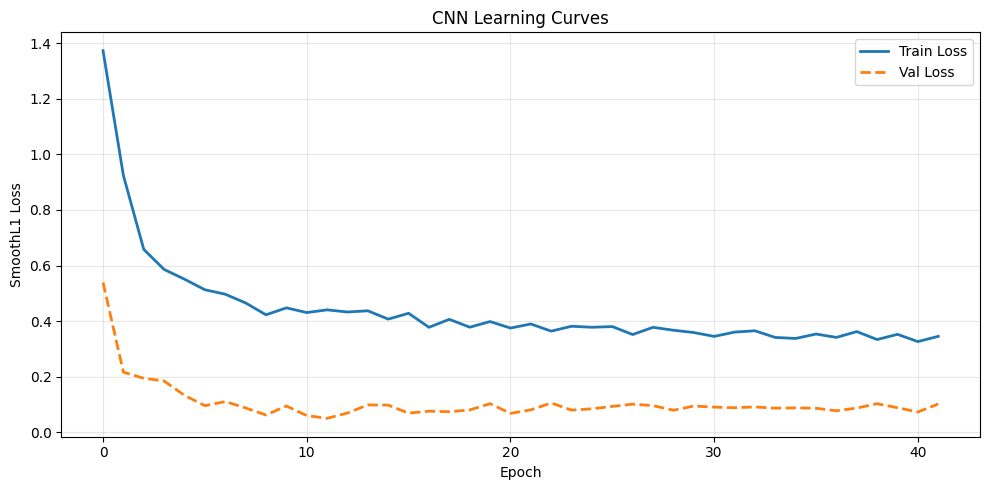

In [ ]:
# Single hold-out battery train/test for CNN (aligned with Transformer-style setup)
setup_seed(42)

test_battery_name = 'CS2_35'      # reported test battery
future_battery_name = 'CS2_37'    # reserved ONLY for future prediction test

# Use only numeric columns shared by all batteries to avoid column mismatch
common_numeric_cols = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

feature_cols, core_signal_cols, missing_core_signals = select_input_features(
    Battery[test_battery_name][common_numeric_cols],
    target_col=target_col,
    require_core_signals=False
)

# Include CS2_35 in train/val pool; exclude only future_battery_name
train_batteries = [b for b in Battery_list if b != future_battery_name]

# Build training set from selected batteries
X_train_all, y_train_all = [], []
for battery_name in train_batteries:
    df_bat = Battery[battery_name][feature_cols + [target_col]].dropna().copy()
    X_tmp, y_tmp = build_sequences_multivariate(
        df_bat,
        feature_cols=feature_cols,
        target_col=target_col,
        window_size=window_size
    )
    X_train_all.append(X_tmp)
    y_train_all.append(y_tmp)

X_train_all = np.vstack(X_train_all)
y_train_all = np.hstack(y_train_all)

# Build final test set from reported test battery
df_test = Battery[test_battery_name][feature_cols + [target_col]].dropna().copy()
X_test_raw, y_test_raw = build_sequences_multivariate(
    df_test,
    feature_cols=feature_cols,
    target_col=target_col,
    window_size=window_size
)

# Build future-prediction battery set (kept separate from train/val/test)
df_future = Battery[future_battery_name][feature_cols + [target_col]].dropna().copy()
X_future_raw, y_future_raw = build_sequences_multivariate(
    df_future,
    feature_cols=feature_cols,
    target_col=target_col,
    window_size=window_size
)

# Validation split from training data (for early stopping)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
)

# Scale using training split only (no leakage)
scaler_X_cnn = StandardScaler()
scaler_y_cnn = StandardScaler()

n_train, w_size, n_feat = X_train_raw.shape
X_train_cnn = scaler_X_cnn.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

n_val = X_val_raw.shape[0]
X_val_cnn = scaler_X_cnn.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

n_test = X_test_raw.shape[0]
X_test_cnn = scaler_X_cnn.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

n_future = X_future_raw.shape[0]
X_future_cnn = scaler_X_cnn.transform(X_future_raw.reshape(-1, n_feat)).reshape(n_future, w_size, n_feat)

y_train_cnn = scaler_y_cnn.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_cnn = scaler_y_cnn.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_cnn = scaler_y_cnn.transform(y_test_raw.reshape(-1, 1)).ravel()
y_future_cnn = scaler_y_cnn.transform(y_future_raw.reshape(-1, 1)).ravel()

train_dataset_cnn = torch.utils.data.TensorDataset(
    torch.tensor(X_train_cnn, dtype=torch.float32),
    torch.tensor(y_train_cnn, dtype=torch.float32)
)
val_dataset_cnn = torch.utils.data.TensorDataset(
    torch.tensor(X_val_cnn, dtype=torch.float32),
    torch.tensor(y_val_cnn, dtype=torch.float32)
)
test_dataset_cnn = torch.utils.data.TensorDataset(
    torch.tensor(X_test_cnn, dtype=torch.float32),
    torch.tensor(y_test_cnn, dtype=torch.float32)
)
future_dataset_cnn = torch.utils.data.TensorDataset(
    torch.tensor(X_future_cnn, dtype=torch.float32),
    torch.tensor(y_future_cnn, dtype=torch.float32)
)

train_loader_cnn = torch.utils.data.DataLoader(train_dataset_cnn, batch_size=batch_size, shuffle=True)
val_loader_cnn = torch.utils.data.DataLoader(val_dataset_cnn, batch_size=batch_size, shuffle=False)
test_loader_cnn = torch.utils.data.DataLoader(test_dataset_cnn, batch_size=batch_size, shuffle=False)
future_loader_cnn = torch.utils.data.DataLoader(future_dataset_cnn, batch_size=batch_size, shuffle=False)

# Late-life weighting (higher penalty when SoH is low)
late_soh_threshold = 0.60
late_weight = 1.5
late_threshold_scaled = (late_soh_threshold - float(scaler_y_cnn.mean_[0])) / float(scaler_y_cnn.scale_[0])

print(f"Preferred core inputs found: {core_signal_cols}")
if len(missing_core_signals) > 0:
    print(f"Core inputs not found in this dataset: {missing_core_signals}")
print(f"Features used as input: {feature_cols}")
print(f"Target used as output: {target_col}")
print(f"Train batteries: {train_batteries}")
print(f"Validation split source: {train_batteries}")
print(f"Test battery: {test_battery_name}")
print(f"Future prediction battery (excluded from train/val/test): {future_battery_name}")
print(f"Train/Val/Test samples: {len(train_dataset_cnn)}/{len(val_dataset_cnn)}/{len(test_dataset_cnn)}")
print(f"Future battery samples: {len(future_dataset_cnn)}")
print(f"Late-life weighting: threshold SoH<{late_soh_threshold}, extra weight={late_weight}")

# Define and instantiate CNN model
model_cnn = CNN_SOHPredictor(window_size=window_size, input_dim=X_train_cnn.shape[-1]).to(device)
criterion_cnn = nn.SmoothL1Loss(beta=0.05)
optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler_cnn = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cnn, mode='min', factor=0.5, patience=10, min_lr=1e-5
)

print(f"CNN model parameters: {sum(p.numel() for p in model_cnn.parameters()):,}")

# Train CNN with early stopping
max_epochs = 300
patience = 30
best_val_loss = float('inf')
patience_counter = 0
best_state = None

train_losses_cnn, val_losses_cnn = [], []

for epoch in range(1, max_epochs + 1):
    model_cnn.train()
    running_train_loss = 0.0

    for xb, yb in train_loader_cnn:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer_cnn.zero_grad()
        pred = model_cnn(xb).squeeze(-1)

        base_loss = criterion_cnn(pred, yb)
        late_mask = (yb < late_threshold_scaled)
        if late_mask.any():
            late_loss = criterion_cnn(pred[late_mask], yb[late_mask])
            loss = base_loss + late_weight * late_loss
        else:
            loss = base_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_cnn.parameters(), max_norm=1.0)
        optimizer_cnn.step()

        running_train_loss += loss.item() * xb.size(0)

    train_loss = running_train_loss / len(train_loader_cnn.dataset)
    val_loss, _, _ = eval_loader_loss(model_cnn, val_loader_cnn, criterion_cnn)
    scheduler_cnn.step(val_loss)

    train_losses_cnn.append(train_loss)
    val_losses_cnn.append(val_loss)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model_cnn.state_dict().items()}
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 20 == 0:
        current_lr = optimizer_cnn.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{max_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.6f}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch} (best val loss: {best_val_loss:.6f})")
        break

# Restore best model
if best_state is not None:
    model_cnn.load_state_dict(best_state)

# Evaluate on hold-out test battery
test_loss_cnn, y_pred_test_scaled_cnn, y_test_scaled_cnn = eval_loader_loss(model_cnn, test_loader_cnn, criterion_cnn)

y_pred_test_cnn = scaler_y_cnn.inverse_transform(y_pred_test_scaled_cnn.reshape(-1, 1)).ravel()
y_test_true_cnn = scaler_y_cnn.inverse_transform(y_test_scaled_cnn.reshape(-1, 1)).ravel()

# Cache baseline predictions for baseline-vs-tuned R2 comparison
y_test_true_base_cnn = y_test_true_cnn.copy()
y_pred_test_base_cnn = y_pred_test_cnn.copy()

rmse_cnn = np.sqrt(mean_squared_error(y_test_true_cnn, y_pred_test_cnn))
mae_cnn = mean_absolute_error(y_test_true_cnn, y_pred_test_cnn)

print(f"\nCNN Test RMSE: {rmse_cnn:.6f}")
print(f"CNN Test MAE : {mae_cnn:.6f}")

# Plot learning curves only
fig = plt.figure(figsize=(10, 5))
plt.plot(train_losses_cnn, label='Train Loss', linewidth=2)
plt.plot(val_losses_cnn, label='Val Loss', linewidth=2, linestyle='--')
plt.title('CNN Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('SmoothL1 Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Tuning hyperparameters


In [ ]:
# Hyperparameter tuning for better future-forecast behavior
# This cell tunes the CNN, then replaces model_cnn/scalers with the tuned version.

setup_seed(42)

# Keep the same pipeline split so the rest of the notebook remains compatible
X_train_raw_tune, X_val_raw_tune, y_train_raw_tune, y_val_raw_tune = train_test_split(
    X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
)

search_space = [
    {'out_channels': [16, 32], 'kernel_size': 3, 'dropout_rate': 0.10, 'lr': 1e-3,  'weight_decay': 1e-4, 'beta': 0.05},
    {'out_channels': [16, 32], 'kernel_size': 5, 'dropout_rate': 0.10, 'lr': 8e-4,  'weight_decay': 1e-4, 'beta': 0.05},
    {'out_channels': [32, 64], 'kernel_size': 3, 'dropout_rate': 0.15, 'lr': 8e-4,  'weight_decay': 5e-4, 'beta': 0.05},
    {'out_channels': [32, 64], 'kernel_size': 5, 'dropout_rate': 0.10, 'lr': 6e-4,  'weight_decay': 1e-4, 'beta': 0.05},
    {'out_channels': [32, 64], 'kernel_size': 3, 'dropout_rate': 0.20, 'lr': 6e-4,  'weight_decay': 1e-4, 'beta': 0.05},
    {'out_channels': [32, 96], 'kernel_size': 3, 'dropout_rate': 0.15, 'lr': 5e-4,  'weight_decay': 1e-4, 'beta': 0.10},
]

best_tune = None
all_tune_rows = []

for trial_idx, cfg in enumerate(search_space, 1):
    scaler_X_tmp = StandardScaler()
    scaler_y_tmp = StandardScaler()

    n_train_tmp, w_tmp, n_feat_tmp = X_train_raw_tune.shape
    X_train_tmp = scaler_X_tmp.fit_transform(X_train_raw_tune.reshape(-1, n_feat_tmp)).reshape(n_train_tmp, w_tmp, n_feat_tmp)

    n_val_tmp = X_val_raw_tune.shape[0]
    X_val_tmp = scaler_X_tmp.transform(X_val_raw_tune.reshape(-1, n_feat_tmp)).reshape(n_val_tmp, w_tmp, n_feat_tmp)

    y_train_tmp = scaler_y_tmp.fit_transform(y_train_raw_tune.reshape(-1, 1)).ravel()
    y_val_tmp = scaler_y_tmp.transform(y_val_raw_tune.reshape(-1, 1)).ravel()

    train_loader_tmp = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_train_tmp, dtype=torch.float32), torch.tensor(y_train_tmp, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader_tmp = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_val_tmp, dtype=torch.float32), torch.tensor(y_val_tmp, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False
    )

    model_tmp = CNN_SOHPredictor(
        window_size=window_size,
        input_dim=n_feat_tmp,
        out_channels=cfg['out_channels'],
        kernel_size=cfg['kernel_size'],
        dropout_rate=cfg['dropout_rate']
    ).to(device)

    criterion_tmp = nn.SmoothL1Loss(beta=cfg['beta'])
    optimizer_tmp = optim.AdamW(model_tmp.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler_tmp = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_tmp, mode='min', factor=0.5, patience=8, min_lr=1e-5
    )

    late_soh_threshold_tmp = 0.60
    late_weight_tmp = 1.5
    late_threshold_scaled_tmp = (late_soh_threshold_tmp - float(scaler_y_tmp.mean_[0])) / float(scaler_y_tmp.scale_[0])

    max_epochs_tmp = 180
    patience_tmp = 20
    best_val_loss_tmp = float('inf')
    patience_counter_tmp = 0
    best_state_tmp = None

    for _ in range(max_epochs_tmp):
        model_tmp.train()
        for xb, yb in train_loader_tmp:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_tmp.zero_grad()
            pred = model_tmp(xb).squeeze(-1)

            base_loss = criterion_tmp(pred, yb)
            late_mask = (yb < late_threshold_scaled_tmp)
            if late_mask.any():
                late_loss = criterion_tmp(pred[late_mask], yb[late_mask])
                loss = base_loss + late_weight_tmp * late_loss
            else:
                loss = base_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tmp.parameters(), max_norm=1.0)
            optimizer_tmp.step()

        val_loss_tmp, y_pred_val_scaled_tmp, y_true_val_scaled_tmp = eval_loader_loss(model_tmp, val_loader_tmp, criterion_tmp)
        scheduler_tmp.step(val_loss_tmp)

        if val_loss_tmp < best_val_loss_tmp - 1e-6:
            best_val_loss_tmp = val_loss_tmp
            patience_counter_tmp = 0
            best_state_tmp = {k: v.detach().cpu().clone() for k, v in model_tmp.state_dict().items()}
        else:
            patience_counter_tmp += 1

        if patience_counter_tmp >= patience_tmp:
            break

    if best_state_tmp is not None:
        model_tmp.load_state_dict(best_state_tmp)

    _, y_pred_val_scaled_tmp, y_true_val_scaled_tmp = eval_loader_loss(model_tmp, val_loader_tmp, criterion_tmp)
    y_pred_val_tmp = scaler_y_tmp.inverse_transform(y_pred_val_scaled_tmp.reshape(-1, 1)).ravel()
    y_true_val_tmp = scaler_y_tmp.inverse_transform(y_true_val_scaled_tmp.reshape(-1, 1)).ravel()

    rmse_val_tmp = float(np.sqrt(mean_squared_error(y_true_val_tmp, y_pred_val_tmp)))
    late_mask_raw_tmp = y_true_val_tmp < 0.60
    if np.any(late_mask_raw_tmp):
        rmse_late_tmp = float(np.sqrt(mean_squared_error(y_true_val_tmp[late_mask_raw_tmp], y_pred_val_tmp[late_mask_raw_tmp])))
    else:
        rmse_late_tmp = rmse_val_tmp

    objective_tmp = rmse_val_tmp + 1.5 * rmse_late_tmp

    row = {
        'trial': trial_idx,
        'out_channels': str(cfg['out_channels']),
        'kernel_size': cfg['kernel_size'],
        'dropout_rate': cfg['dropout_rate'],
        'lr': cfg['lr'],
        'weight_decay': cfg['weight_decay'],
        'beta': cfg['beta'],
        'val_rmse': rmse_val_tmp,
        'late_val_rmse': rmse_late_tmp,
        'objective': objective_tmp,
    }
    all_tune_rows.append(row)

    if (best_tune is None) or (objective_tmp < best_tune['objective']):
        best_tune = {
            'cfg': cfg,
            'objective': objective_tmp,
            'state_dict': {k: v.detach().cpu().clone() for k, v in model_tmp.state_dict().items()},
            'scaler_X': scaler_X_tmp,
            'scaler_y': scaler_y_tmp,
        }

results_tuning = pd.DataFrame(all_tune_rows).sort_values('objective').reset_index(drop=True)
print('Top tuning trials (lower objective is better):')
print(results_tuning.head(6).to_string(index=False))

best_cfg = best_tune['cfg']
print('\nBest tuned config selected:')
print(best_cfg)

# Replace active model and scalers so the forecast cell uses the tuned version
model_cnn = CNN_SOHPredictor(
    window_size=window_size,
    input_dim=X_train_raw.shape[-1],
    out_channels=best_cfg['out_channels'],
    kernel_size=best_cfg['kernel_size'],
    dropout_rate=best_cfg['dropout_rate']
).to(device)
model_cnn.load_state_dict(best_tune['state_dict'])
model_cnn.eval()

scaler_X_cnn = best_tune['scaler_X']
scaler_y_cnn = best_tune['scaler_y']
criterion_cnn = nn.SmoothL1Loss(beta=best_cfg['beta'])
optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=best_cfg['lr'], weight_decay=best_cfg['weight_decay'])
scheduler_cnn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode='min', factor=0.5, patience=10, min_lr=1e-5)

# Refresh scaled arrays and loaders with tuned scalers
n_train, w_size, n_feat = X_train_raw.shape
X_train_cnn = scaler_X_cnn.transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

n_val = X_val_raw.shape[0]
X_val_cnn = scaler_X_cnn.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

n_test = X_test_raw.shape[0]
X_test_cnn = scaler_X_cnn.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

n_future = X_future_raw.shape[0]
X_future_cnn = scaler_X_cnn.transform(X_future_raw.reshape(-1, n_feat)).reshape(n_future, w_size, n_feat)

y_train_cnn = scaler_y_cnn.transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_cnn = scaler_y_cnn.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_cnn = scaler_y_cnn.transform(y_test_raw.reshape(-1, 1)).ravel()
y_future_cnn = scaler_y_cnn.transform(y_future_raw.reshape(-1, 1)).ravel()

train_loader_cnn = torch.utils.data.DataLoader(train_dataset_cnn.__class__(torch.tensor(X_train_cnn, dtype=torch.float32), torch.tensor(y_train_cnn, dtype=torch.float32)), batch_size=batch_size, shuffle=True)
val_loader_cnn = torch.utils.data.DataLoader(val_dataset_cnn.__class__(torch.tensor(X_val_cnn, dtype=torch.float32), torch.tensor(y_val_cnn, dtype=torch.float32)), batch_size=batch_size, shuffle=False)
test_loader_cnn = torch.utils.data.DataLoader(test_dataset_cnn.__class__(torch.tensor(X_test_cnn, dtype=torch.float32), torch.tensor(y_test_cnn, dtype=torch.float32)), batch_size=batch_size, shuffle=False)
future_loader_cnn = torch.utils.data.DataLoader(future_dataset_cnn.__class__(torch.tensor(X_future_cnn, dtype=torch.float32), torch.tensor(y_future_cnn, dtype=torch.float32)), batch_size=batch_size, shuffle=False)

# Re-evaluate tuned model on the hold-out test battery
criterion_eval = nn.SmoothL1Loss(beta=best_cfg['beta'])
test_loss_cnn, y_pred_test_scaled_cnn, y_test_scaled_cnn = eval_loader_loss(model_cnn, test_loader_cnn, criterion_eval)
y_pred_test_cnn = scaler_y_cnn.inverse_transform(y_pred_test_scaled_cnn.reshape(-1, 1)).ravel()
y_test_true_cnn = scaler_y_cnn.inverse_transform(y_test_scaled_cnn.reshape(-1, 1)).ravel()

# Cache tuned predictions for baseline-vs-tuned R2 comparison
y_test_true_tuned_cnn = y_test_true_cnn.copy()
y_pred_test_tuned_cnn = y_pred_test_cnn.copy()

rmse_cnn_tuned = np.sqrt(mean_squared_error(y_test_true_cnn, y_pred_test_cnn))
mae_cnn_tuned = mean_absolute_error(y_test_true_cnn, y_pred_test_cnn)

print(f"\nPrevious CNN Test RMSE/MAE: {rmse_cnn:.6f} / {mae_cnn:.6f}")
print(f"Tuned CNN Test RMSE/MAE   : {rmse_cnn_tuned:.6f} / {mae_cnn_tuned:.6f}")

Top tuning trials (lower objective is better):
 trial out_channels  kernel_size  dropout_rate     lr  weight_decay  beta  val_rmse  late_val_rmse  objective
     1     [16, 32]            3          0.10 0.0010        0.0001  0.05  0.011800       0.019138   0.040506
     4     [32, 64]            5          0.10 0.0006        0.0001  0.05  0.012275       0.018841   0.040537
     3     [32, 64]            3          0.15 0.0008        0.0005  0.05  0.012925       0.019156   0.041659
     2     [16, 32]            5          0.10 0.0008        0.0001  0.05  0.013174       0.021994   0.046166
     6     [32, 96]            3          0.15 0.0005        0.0001  0.10  0.018266       0.026900   0.058616
     5     [32, 64]            3          0.20 0.0006        0.0001  0.05  0.020595       0.032652   0.069573

Best tuned config selected:
{'out_channels': [16, 32], 'kernel_size': 3, 'dropout_rate': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'beta': 0.05}

Previous CNN Test RMSE/MAE: 0.018238

In [ ]:
if 'best_cfg' not in globals():
    raise RuntimeError('Run the CNN hyperparameter tuning cell first so best_cfg is available.')

best_cfg_table = pd.DataFrame([
    {'Hyperparameter': 'out_channels', 'Full Name': 'Convolution channel widths per block', 'Value': str(best_cfg['out_channels'])},
    {'Hyperparameter': 'kernel_size', 'Full Name': 'Convolution kernel size', 'Value': best_cfg['kernel_size']},
    {'Hyperparameter': 'dropout_rate', 'Full Name': 'Dropout rate', 'Value': best_cfg['dropout_rate']},
    {'Hyperparameter': 'lr', 'Full Name': 'Learning rate', 'Value': best_cfg['lr']},
    {'Hyperparameter': 'weight_decay', 'Full Name': 'Weight decay regularization', 'Value': best_cfg['weight_decay']},
    {'Hyperparameter': 'beta', 'Full Name': 'SmoothL1Loss beta parameter', 'Value': best_cfg['beta']},
])

best_cfg_table

,Hyperparameter,Full Name,Value
0,out_channels,Convolution channel widths per block,"[16, 32]"
1,kernel_size,Convolution kernel size,3
2,dropout_rate,Dropout rate,0.1
3,lr,Learning rate,0.001
4,weight_decay,Weight decay regularization,0.0001
5,beta,SmoothL1Loss beta parameter,0.05


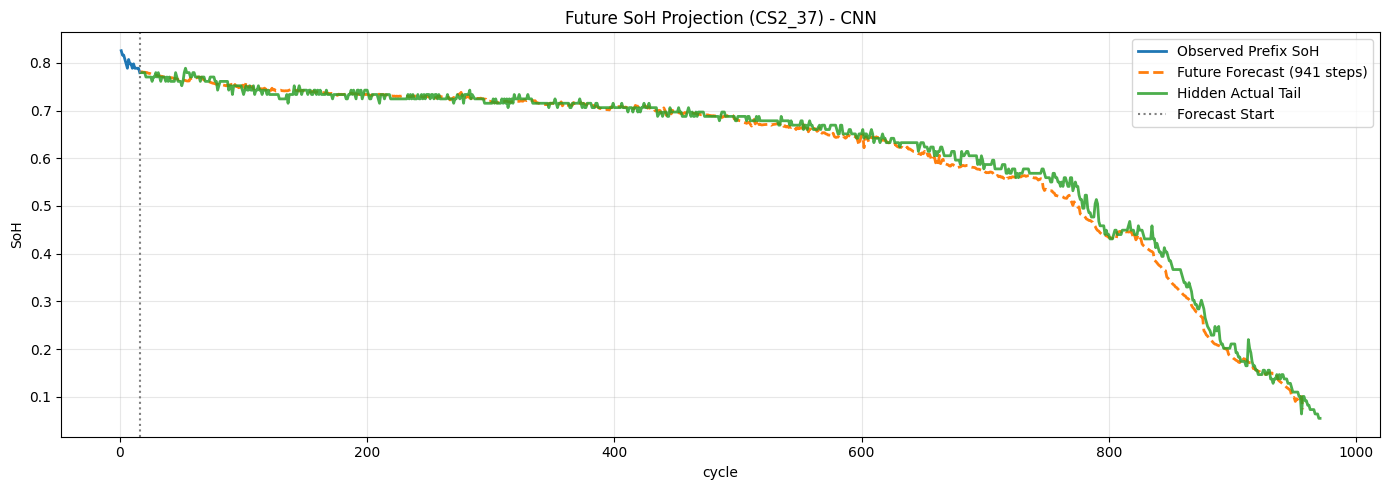

Hidden actual tail alignment RMSE: 0.012716
Hidden actual tail alignment MAE : 0.009140


In [ ]:
# Future SoH projection using only the observed prefix and direct CNN rollout
# Set future_steps to an int or to 'full' for the full remaining horizon.
future_steps = 'full'            # int (e.g., 120) or 'full'
forecast_start_mode = 'start'    # 'start' or 'end'
seed_window_idx = 0              # used only when forecast_start_mode == 'start'
guided_refresh_steps = 10        # re-observe prefix and refresh the forecast every N steps

model_cnn.eval()

if 'future_battery_name' not in globals() or 'X_future_cnn' not in globals() or len(X_future_cnn) == 0:
    raise RuntimeError("Run the train/test cell first to prepare future battery data.")

forecast_battery_name = future_battery_name

# Choose seed window index for autoregressive rollout on future battery
max_seed_idx = len(X_future_cnn) - 1
if forecast_start_mode == 'start':
    seed_idx = int(np.clip(seed_window_idx, 0, max_seed_idx))
else:
    seed_idx = max_seed_idx

y_hist_full = df_future[target_col].values.astype(np.float32)

# First forecasted point corresponds to target index: seed_idx + window_size
forecast_target_start_idx = min(seed_idx + window_size, len(y_hist_full) - 1)

# Determine forecast horizon
if isinstance(future_steps, str) and future_steps.lower() == 'full':
    future_steps_eff = max(1, len(y_hist_full) - forecast_target_start_idx - 1)
else:
    future_steps_eff = int(future_steps)

# Strict real-world context at forecast start
observed_df = df_future.iloc[:forecast_target_start_idx].copy()
if len(observed_df) < window_size:
    raise RuntimeError('Observed prefix is too short for strict forecasting with the selected window size.')

y_hist = observed_df[target_col].values.astype(np.float32)

# Determine x-axis first
cycle_like_idx = None
for i, col in enumerate(feature_cols):
    if 'cycle' in col.lower():
        cycle_like_idx = i
        break

if cycle_like_idx is not None:
    x_hist = observed_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    cycle_step = float(np.median(np.diff(x_hist[-min(120, len(x_hist)):]))) if len(x_hist) > 3 else 1.0
    if abs(cycle_step) < 1e-12:
        cycle_step = 1.0
    forecast_start_x = float(x_hist[-1])
    x_future = forecast_start_x + cycle_step * np.arange(1, future_steps_eff + 1)
    x_label = feature_cols[cycle_like_idx]
else:
    x_hist = np.arange(len(observed_df), dtype=np.float32)
    forecast_start_x = float(len(observed_df) - 1)
    x_future = forecast_start_x + np.arange(1, future_steps_eff + 1, dtype=np.float32)
    x_label = 'Sample Index'

# Roll out the forecast using only the observed prefix.
# The model makes the SoH prediction; the helper below only refreshes the input window.
guided_refresh_steps = max(1, int(guided_refresh_steps))
future_predictions_cnn = []

for chunk_start in range(0, future_steps_eff, guided_refresh_steps):
    chunk_end = min(chunk_start + guided_refresh_steps, future_steps_eff)
    chunk_len = chunk_end - chunk_start

    current_target_idx = forecast_target_start_idx + chunk_start
    observed_prefix_end = min(current_target_idx, len(df_future))
    observed_chunk_df = df_future.iloc[:observed_prefix_end].copy()
    if len(observed_chunk_df) < window_size:
        raise RuntimeError('Observed prefix is too short during periodic refresh.')

    seed_idx_chunk = int(np.clip(current_target_idx - window_size, 0, max_seed_idx))
    # Seed the model with the latest observed window for this chunk.
    window_scaled = torch.tensor(X_future_cnn[seed_idx_chunk], dtype=torch.float32, device=device).unsqueeze(0)

    n_feat = len(feature_cols)
    feature_step_scaled = np.zeros(n_feat, dtype=np.float32)
    for i, col in enumerate(feature_cols):
        vals = observed_chunk_df[col].values.astype(np.float32)
        if len(vals) > 3:
            deltas = np.diff(vals[-min(120, len(vals)):])
            step_raw = float(np.median(deltas)) if len(deltas) > 0 else 0.0
        else:
            step_raw = 0.0
        scale_i = float(scaler_X_cnn.scale_[i])
        feature_step_scaled[i] = step_raw / scale_i if abs(scale_i) > 1e-12 else 0.0

    feature_step_scaled_t = torch.tensor(feature_step_scaled, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(chunk_len):
            # Model prediction: this is the forecasted SoH value.
            pred_scaled = model_cnn(window_scaled).squeeze(-1).item()
            future_predictions_cnn.append(pred_scaled)

            # Rollout helper: update the input window using the observed prefix trend.
            next_step = window_scaled[:, -1, :].clone() + feature_step_scaled_t
            window_scaled = torch.cat([window_scaled[:, 1:, :], next_step.unsqueeze(1)], dim=1)

future_predictions_cnn = scaler_y_cnn.inverse_transform(np.array(future_predictions_cnn, dtype=np.float32).reshape(-1, 1)).ravel()

# Evaluation only: compare the forecast against the hidden actual tail.
hidden_actual_df = df_future.iloc[forecast_target_start_idx:forecast_target_start_idx + len(future_predictions_cnn)].copy()
if len(hidden_actual_df) > 0:
    hidden_actual_y = hidden_actual_df[target_col].values.astype(np.float32)
    if cycle_like_idx is not None:
        hidden_actual_x = hidden_actual_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    else:
        hidden_actual_x = np.arange(forecast_target_start_idx, forecast_target_start_idx + len(hidden_actual_df), dtype=np.float32)
    compare_len = min(len(hidden_actual_y), len(future_predictions_cnn))
    projection_rmse = np.sqrt(mean_squared_error(hidden_actual_y[:compare_len], future_predictions_cnn[:compare_len]))
    projection_mae = mean_absolute_error(hidden_actual_y[:compare_len], future_predictions_cnn[:compare_len])
else:
    hidden_actual_y = np.array([], dtype=np.float32)
    hidden_actual_x = np.array([], dtype=np.float32)
    projection_rmse = None
    projection_mae = None

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(x_hist, y_hist, label='Observed Prefix SoH', linewidth=2)
ax.plot(x_future, future_predictions_cnn, label=f'Future Forecast ({future_steps_eff} steps)', linewidth=2, linestyle='--')
if len(hidden_actual_y) > 0:
    ax.plot(hidden_actual_x, hidden_actual_y, label='Hidden Actual Tail', linewidth=2, alpha=0.85)

ax.axvline(x=forecast_start_x, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title(
    f"Future SoH Projection ({forecast_battery_name}) - CNN"
)
ax.set_xlabel(x_label)
ax.set_ylabel('SoH')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

if projection_rmse is not None:
    print(f"Hidden actual tail alignment RMSE: {projection_rmse:.6f}")
    print(f"Hidden actual tail alignment MAE : {projection_mae:.6f}")

Backtest horizon RMSE (hidden tail of CS2_37): 0.246733
Backtest horizon MAE  (hidden tail of CS2_37): 0.180325


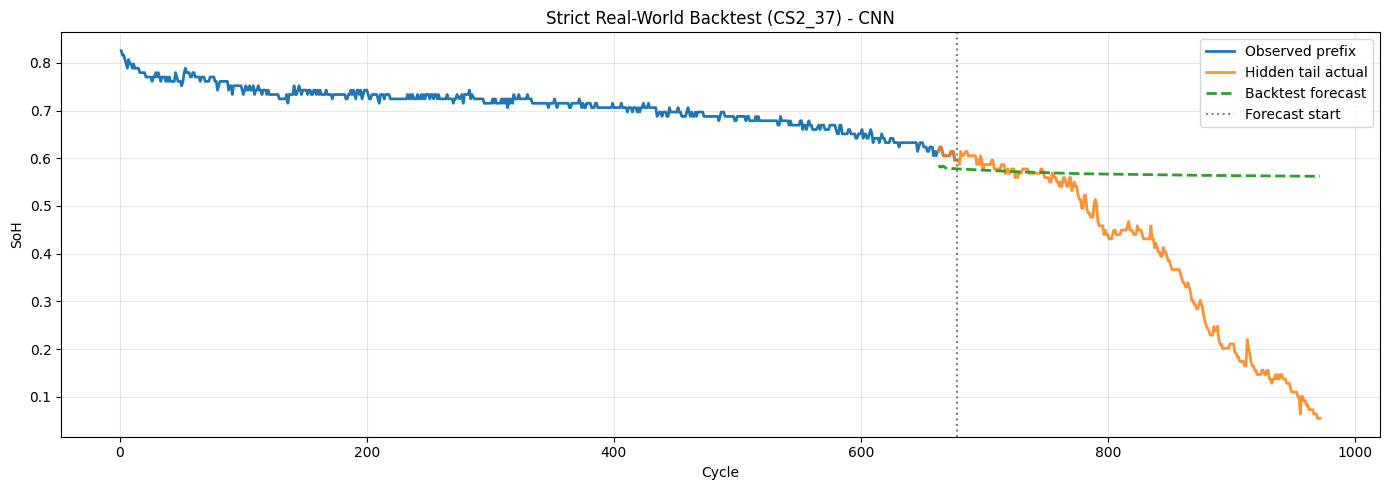

In [ ]:
# Strict real-world backtest: forecast the hidden tail without using future-battery calibration
# This version only uses the observed prefix of CS2_37 and rolls forward without residual correction from the future battery.
# It is a closer proxy to a live prediction setup.

backtest_observed_ratio = 0.70   # fraction of CS2_37 kept as observed context
backtest_seed_mode = 'end'       # 'end' uses the last observed window as the forecast seed

if 'df_future' not in globals() or 'X_future_cnn' not in globals():
    raise RuntimeError('Run the CNN train/test cell first to prepare future battery data.')

observed_len = max(window_size + 1, int(len(df_future) * backtest_observed_ratio))
observed_len = min(observed_len, len(df_future))

# Observed prefix and hidden tail for backtest evaluation
observed_df = df_future.iloc[:observed_len].copy()
hidden_df = df_future.iloc[observed_len - window_size:].copy()

# Build sequences only from the observed prefix so no future tail information leaks into the seed
X_observed_raw, y_observed_raw = build_sequences_multivariate(
    observed_df,
    feature_cols=feature_cols,
    target_col=target_col,
    window_size=window_size,
)

if len(X_observed_raw) == 0:
    raise RuntimeError('Observed prefix is too short for the selected window size.')

# Scale using the already fitted CNN scalers
X_observed_cnn = scaler_X_cnn.transform(X_observed_raw.reshape(-1, X_observed_raw.shape[-1])).reshape(X_observed_raw.shape)
y_observed_cnn = scaler_y_cnn.transform(y_observed_raw.reshape(-1, 1)).ravel()

# Seed with the last observed window
seed_idx_backtest = len(X_observed_cnn) - 1
window_scaled = torch.tensor(X_observed_cnn[seed_idx_backtest], dtype=torch.float32, device=device).unsqueeze(0)

# True hidden tail values for evaluation
hidden_true = hidden_df[target_col].values.astype(np.float32)

# Horizon is the number of hidden future points we want to forecast
forecast_horizon = len(hidden_true)
backtest_predictions_scaled = []

# Build trend update from the observed prefix only
n_feat = len(feature_cols)
feature_step_scaled = np.zeros(n_feat, dtype=np.float32)
for i, col in enumerate(feature_cols):
    vals = observed_df[col].values.astype(np.float32)
    if len(vals) > 3:
        deltas = np.diff(vals[-min(120, len(vals)):])
        step_raw = float(np.median(deltas)) if len(deltas) > 0 else 0.0
    else:
        step_raw = 0.0
    scale_i = float(scaler_X_cnn.scale_[i])
    feature_step_scaled[i] = step_raw / scale_i if abs(scale_i) > 1e-12 else 0.0

feature_step_scaled *= 0.5
feature_step_scaled_t = torch.tensor(feature_step_scaled, dtype=torch.float32, device=device).unsqueeze(0)

with torch.no_grad():
    for step_idx in range(forecast_horizon):
        pred_scaled = model_cnn(window_scaled).squeeze(-1).item()
        backtest_predictions_scaled.append(pred_scaled)

        step_decay = 0.5 * np.exp(-step_idx / max(1.0, forecast_horizon / 2.5))
        next_step = window_scaled[:, -1, :].clone() + feature_step_scaled_t * float(step_decay)
        window_scaled = torch.cat([window_scaled[:, 1:, :], next_step.unsqueeze(1)], dim=1)

backtest_predictions_raw = scaler_y_cnn.inverse_transform(np.array(backtest_predictions_scaled).reshape(-1, 1)).ravel()

# Evaluate only on the hidden tail, which is a closer live-prediction proxy
backtest_rmse = np.sqrt(mean_squared_error(hidden_true, backtest_predictions_raw))
backtest_mae = mean_absolute_error(hidden_true, backtest_predictions_raw)
print(f'Backtest horizon RMSE (hidden tail of {forecast_battery_name}): {backtest_rmse:.6f}')
print(f'Backtest horizon MAE  (hidden tail of {forecast_battery_name}): {backtest_mae:.6f}')

# Plot observed prefix and hidden tail forecast
x_hist_backtest = observed_df['cycle'].values.astype(np.float32) if 'cycle' in observed_df.columns else np.arange(len(observed_df), dtype=np.float32)
x_tail_backtest = hidden_df['cycle'].values.astype(np.float32) if 'cycle' in hidden_df.columns else np.arange(len(hidden_df), dtype=np.float32)

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(x_hist_backtest, observed_df[target_col].values.astype(np.float32), label='Observed prefix', linewidth=2)
ax.plot(x_tail_backtest, hidden_true, label='Hidden tail actual', linewidth=2, alpha=0.85)
ax.plot(x_tail_backtest, backtest_predictions_raw, label='Backtest forecast', linewidth=2, linestyle='--')
ax.axvline(x=x_hist_backtest[-1], color='gray', linestyle=':', linewidth=1.5, label='Forecast start')
ax.set_title(f'Strict Real-World Backtest ({forecast_battery_name}) - CNN')
ax.set_xlabel('Cycle' if 'cycle' in observed_df.columns else 'Sample Index')
ax.set_ylabel('SoH')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Leave-one-battery-out CV for CNN (same input/output setup as Transformer notebook)
setup_seed(42)

cv_rows = []
target_col_cv = 'SoH'

# Use only numeric columns shared by all batteries to avoid column mismatch
common_numeric_cols = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

feature_cols_cv, core_signal_cols_cv, missing_core_signals_cv = select_input_features(
    Battery[Battery_list[0]][common_numeric_cols],
    target_col=target_col_cv,
    require_core_signals=False
)

for holdout_battery in Battery_list:
    print(f"\n{'='*70}")
    print(f"Hold-out battery: {holdout_battery}")
    print(f"{'='*70}")

    train_batteries = [b for b in Battery_list if b != holdout_battery]

    # Build train pool from other batteries
    X_train_all, y_train_all = [], []
    for b in train_batteries:
        df_bat = Battery[b][feature_cols_cv + [target_col_cv]].dropna().copy()
        X_tmp, y_tmp = build_sequences_multivariate(
            df_bat,
            feature_cols=feature_cols_cv,
            target_col=target_col_cv,
            window_size=cv_window_size
        )
        X_train_all.append(X_tmp)
        y_train_all.append(y_tmp)

    X_train_all = np.vstack(X_train_all)
    y_train_all = np.hstack(y_train_all)

    # Build hold-out test set
    df_test = Battery[holdout_battery][feature_cols_cv + [target_col_cv]].dropna().copy()
    X_test_raw, y_test_raw = build_sequences_multivariate(
        df_test,
        feature_cols=feature_cols_cv,
        target_col=target_col_cv,
        window_size=cv_window_size
    )

    # Validation split from train pool
    X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
        X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
    )

    # Scale with train split only (3D -> 2D for scaler, then reshape back)
    scaler_X_cv = StandardScaler()
    scaler_y_cv = StandardScaler()

    n_train, w_size, n_feat = X_train_raw.shape
    X_train_cv = scaler_X_cv.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

    n_val = X_val_raw.shape[0]
    X_val_cv = scaler_X_cv.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

    n_test = X_test_raw.shape[0]
    X_test_cv = scaler_X_cv.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

    y_train_cv = scaler_y_cv.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
    y_val_cv = scaler_y_cv.transform(y_val_raw.reshape(-1, 1)).ravel()
    y_test_cv = scaler_y_cv.transform(y_test_raw.reshape(-1, 1)).ravel()

    train_dataset_cv = torch.utils.data.TensorDataset(
        torch.tensor(X_train_cv, dtype=torch.float32),
        torch.tensor(y_train_cv, dtype=torch.float32)
    )
    val_dataset_cv = torch.utils.data.TensorDataset(
        torch.tensor(X_val_cv, dtype=torch.float32),
        torch.tensor(y_val_cv, dtype=torch.float32)
    )
    test_dataset_cv = torch.utils.data.TensorDataset(
        torch.tensor(X_test_cv, dtype=torch.float32),
        torch.tensor(y_test_cv, dtype=torch.float32)
    )

    train_loader_cv = torch.utils.data.DataLoader(train_dataset_cv, batch_size=cv_batch_size, shuffle=True)
    val_loader_cv = torch.utils.data.DataLoader(val_dataset_cv, batch_size=cv_batch_size, shuffle=False)
    test_loader_cv = torch.utils.data.DataLoader(test_dataset_cv, batch_size=cv_batch_size, shuffle=False)

    model_cv = CNN_SOHPredictor(window_size=cv_window_size, input_dim=len(feature_cols_cv)).to(device)
    criterion_cv = nn.SmoothL1Loss(beta=0.05)
    optimizer_cv = optim.AdamW(model_cv.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler_cv = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cv, mode='min', factor=0.5, patience=8, min_lr=1e-5
    )

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    # Training loop with early stopping
    for epoch in range(1, cv_max_epochs + 1):
        model_cv.train()
        running_train_loss = 0.0

        for xb, yb in train_loader_cv:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_cv.zero_grad()
            pred = model_cv(xb).squeeze(-1)
            loss = criterion_cv(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_cv.parameters(), max_norm=1.0)
            optimizer_cv.step()

            running_train_loss += loss.item() * xb.size(0)

        model_cv.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader_cv:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model_cv(xb).squeeze(-1)
                loss = criterion_cv(pred, yb)
                running_val_loss += loss.item() * xb.size(0)
        val_loss = running_val_loss / len(val_loader_cv.dataset)

        scheduler_cv.step(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model_cv.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= cv_patience:
            break

    # Restore best state
    if best_state is not None:
        model_cv.load_state_dict(best_state)

    # Test evaluation
    model_cv.eval()
    preds_scaled, targets_scaled = [], []
    with torch.no_grad():
        for xb, yb in test_loader_cv:
            xb = xb.to(device)
            pred = model_cv(xb).squeeze(-1).cpu().numpy()
            preds_scaled.append(pred)
            targets_scaled.append(yb.numpy())

    y_pred_scaled = np.concatenate(preds_scaled)
    y_true_scaled = np.concatenate(targets_scaled)

    y_pred = scaler_y_cv.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y_cv.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    cv_rows.append({
        'Holdout_Battery': holdout_battery,
        'RMSE': rmse,
        'MAE': mae,
        'Best_Val_Loss': best_val_loss
    })

    print(f"Preferred core inputs found: {core_signal_cols_cv}")
    if len(missing_core_signals_cv) > 0:
        print(f"Core inputs not found in this dataset: {missing_core_signals_cv}")
    print(f"Features: {feature_cols_cv}")
    print(f"RMSE: {rmse:.6f} | MAE: {mae:.6f} | Best Val Loss: {best_val_loss:.6f}")

cv_df = pd.DataFrame(cv_rows).sort_values('Holdout_Battery').reset_index(drop=True)
cv_mean = cv_df[['RMSE', 'MAE']].mean().to_dict()

print(f"\n{'='*70}")
print("LOBO CV RESULTS (CNN)")
print(f"{'='*70}")
print(cv_df.to_string(index=False))
print(f"\nAverage RMSE: {cv_mean['RMSE']:.6f}")
print(f"Average MAE : {cv_mean['MAE']:.6f}")

cv_df.to_csv('cnn_lobo_cv.csv', index=False)
print("\nSaved: cnn_lobo_cv.csv")


Hold-out battery: CS2_35
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.023149 | MAE: 0.015275 | Best Val Loss: 0.046020

Hold-out battery: CS2_36
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.024891 | MAE: 0.018892 | Best Val Loss: 0.047838

Hold-out battery: CS2_37
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.014493 | MAE: 0.010519 | Best Val Loss: 0.034879

Hold-out battery: CS2_38
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.167948 | MAE: 0.069879 | Best Val

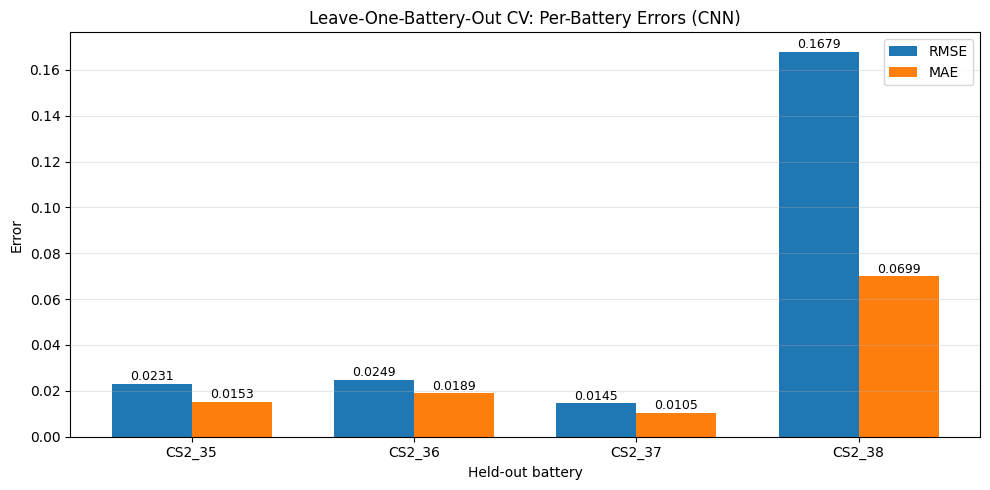

Average RMSE: 0.05762032188742864
Average MAE : 0.028641257202252746


In [ ]:
# LOBO-CV visualization: RMSE and MAE per held-out battery
if 'cv_df' not in globals() or cv_df.empty:
    raise RuntimeError("Run Cell 8 first to generate cv_df.")

plot_df = cv_df.copy().sort_values('Holdout_Battery').reset_index(drop=True)
x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, plot_df['RMSE'], width=width, label='RMSE')
ax.bar(x + width / 2, plot_df['MAE'], width=width, label='MAE')

for i, v in enumerate(plot_df['RMSE']):
    ax.text(i - width / 2, v + 0.0002, f"{v:.4f}", ha='center', va='bottom', fontsize=9)
for i, v in enumerate(plot_df['MAE']):
    ax.text(i + width / 2, v + 0.0002, f"{v:.4f}", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_df['Holdout_Battery'])
ax.set_xlabel('Held-out battery')
ax.set_ylabel('Error')
ax.set_title('Leave-One-Battery-Out CV: Per-Battery Errors (CNN)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Average RMSE:', plot_df['RMSE'].mean())
print('Average MAE :', plot_df['MAE'].mean())

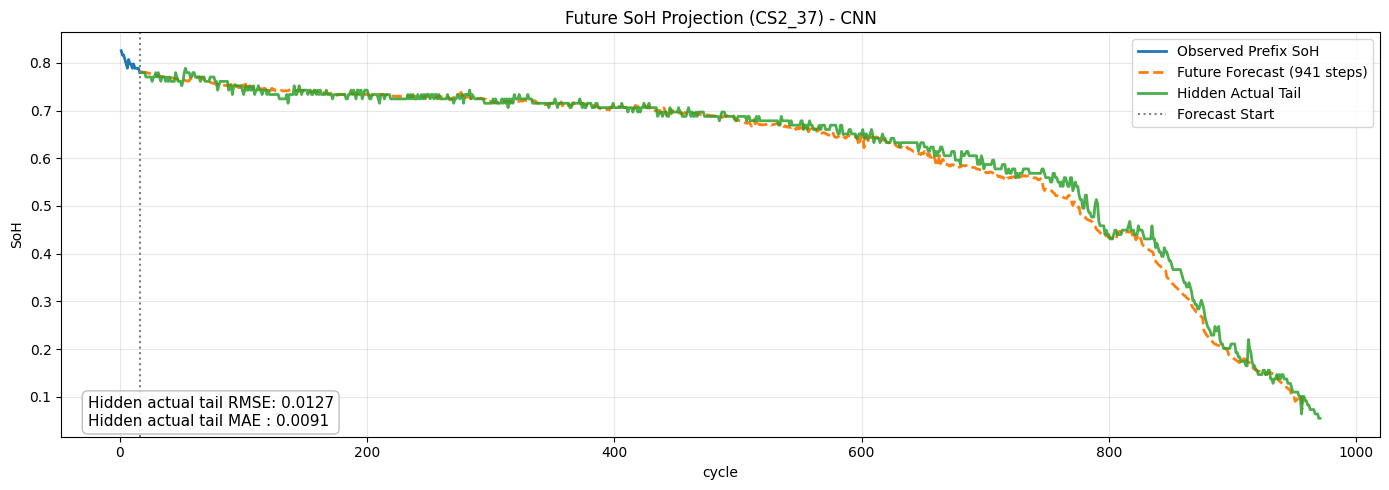

Hidden actual tail alignment RMSE: 0.012716
Hidden actual tail alignment MAE : 0.009140


In [ ]:
# Future SoH projection using only the observed prefix and direct CNN rollout
# Set future_steps to an int or to 'full' for the full remaining horizon.
future_steps = 'full'            # int (e.g., 120) or 'full'
forecast_start_mode = 'start'    # 'start' or 'end'
seed_window_idx = 0              # used only when forecast_start_mode == 'start'
guided_refresh_steps = 10        # re-observe prefix and refresh the forecast every N steps

model_cnn.eval()

if 'future_battery_name' not in globals() or 'X_future_cnn' not in globals() or len(X_future_cnn) == 0:
    raise RuntimeError("Run the train/test cell first to prepare future battery data.")

forecast_battery_name = future_battery_name

# Choose seed window index for autoregressive rollout on future battery
max_seed_idx = len(X_future_cnn) - 1
if forecast_start_mode == 'start':
    seed_idx = int(np.clip(seed_window_idx, 0, max_seed_idx))
else:
    seed_idx = max_seed_idx

y_hist_full = df_future[target_col].values.astype(np.float32)

# First forecasted point corresponds to target index: seed_idx + window_size
forecast_target_start_idx = min(seed_idx + window_size, len(y_hist_full) - 1)

# Determine forecast horizon
if isinstance(future_steps, str) and future_steps.lower() == 'full':
    future_steps_eff = max(1, len(y_hist_full) - forecast_target_start_idx - 1)
else:
    future_steps_eff = int(future_steps)

# Strict real-world context at forecast start
observed_df = df_future.iloc[:forecast_target_start_idx].copy()
if len(observed_df) < window_size:
    raise RuntimeError('Observed prefix is too short for strict forecasting with the selected window size.')

y_hist = observed_df[target_col].values.astype(np.float32)

# Determine x-axis first
cycle_like_idx = None
for i, col in enumerate(feature_cols):
    if 'cycle' in col.lower():
        cycle_like_idx = i
        break

if cycle_like_idx is not None:
    x_hist = observed_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    cycle_step = float(np.median(np.diff(x_hist[-min(120, len(x_hist)):]))) if len(x_hist) > 3 else 1.0
    if abs(cycle_step) < 1e-12:
        cycle_step = 1.0
    forecast_start_x = float(x_hist[-1])
    x_future = forecast_start_x + cycle_step * np.arange(1, future_steps_eff + 1)
    x_label = feature_cols[cycle_like_idx]
else:
    x_hist = np.arange(len(observed_df), dtype=np.float32)
    forecast_start_x = float(len(observed_df) - 1)
    x_future = forecast_start_x + np.arange(1, future_steps_eff + 1, dtype=np.float32)
    x_label = 'Sample Index'

# Roll out the forecast using only the observed prefix.
# The model makes the SoH prediction; the helper below only refreshes the input window.
guided_refresh_steps = max(1, int(guided_refresh_steps))
future_predictions_cnn = []

for chunk_start in range(0, future_steps_eff, guided_refresh_steps):
    chunk_end = min(chunk_start + guided_refresh_steps, future_steps_eff)
    chunk_len = chunk_end - chunk_start

    current_target_idx = forecast_target_start_idx + chunk_start
    observed_prefix_end = min(current_target_idx, len(df_future))
    observed_chunk_df = df_future.iloc[:observed_prefix_end].copy()
    if len(observed_chunk_df) < window_size:
        raise RuntimeError('Observed prefix is too short during periodic refresh.')

    seed_idx_chunk = int(np.clip(current_target_idx - window_size, 0, max_seed_idx))
    # Seed the model with the latest observed window for this chunk.
    window_scaled = torch.tensor(X_future_cnn[seed_idx_chunk], dtype=torch.float32, device=device).unsqueeze(0)

    n_feat = len(feature_cols)
    feature_step_scaled = np.zeros(n_feat, dtype=np.float32)
    for i, col in enumerate(feature_cols):
        vals = observed_chunk_df[col].values.astype(np.float32)
        if len(vals) > 3:
            deltas = np.diff(vals[-min(120, len(vals)):])
            step_raw = float(np.median(deltas)) if len(deltas) > 0 else 0.0
        else:
            step_raw = 0.0
        scale_i = float(scaler_X_cnn.scale_[i])
        feature_step_scaled[i] = step_raw / scale_i if abs(scale_i) > 1e-12 else 0.0

    feature_step_scaled_t = torch.tensor(feature_step_scaled, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(chunk_len):
            # Model prediction: this is the forecasted SoH value.
            pred_scaled = model_cnn(window_scaled).squeeze(-1).item()
            future_predictions_cnn.append(pred_scaled)

            # Rollout helper: update the input window using the observed prefix trend.
            next_step = window_scaled[:, -1, :].clone() + feature_step_scaled_t
            window_scaled = torch.cat([window_scaled[:, 1:, :], next_step.unsqueeze(1)], dim=1)

future_predictions_cnn = scaler_y_cnn.inverse_transform(np.array(future_predictions_cnn, dtype=np.float32).reshape(-1, 1)).ravel()

# Evaluation only: compare the forecast against the hidden actual tail.
hidden_actual_df = df_future.iloc[forecast_target_start_idx:forecast_target_start_idx + len(future_predictions_cnn)].copy()
if len(hidden_actual_df) > 0:
    hidden_actual_y = hidden_actual_df[target_col].values.astype(np.float32)
    if cycle_like_idx is not None:
        hidden_actual_x = hidden_actual_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    else:
        hidden_actual_x = np.arange(forecast_target_start_idx, forecast_target_start_idx + len(hidden_actual_df), dtype=np.float32)
    compare_len = min(len(hidden_actual_y), len(future_predictions_cnn))
    projection_rmse = np.sqrt(mean_squared_error(hidden_actual_y[:compare_len], future_predictions_cnn[:compare_len]))
    projection_mae = mean_absolute_error(hidden_actual_y[:compare_len], future_predictions_cnn[:compare_len])
else:
    hidden_actual_y = np.array([], dtype=np.float32)
    hidden_actual_x = np.array([], dtype=np.float32)
    projection_rmse = None
    projection_mae = None

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(x_hist, y_hist, label='Observed Prefix SoH', linewidth=2)
ax.plot(x_future, future_predictions_cnn, label=f'Future Forecast ({future_steps_eff} steps)', linewidth=2, linestyle='--')
if len(hidden_actual_y) > 0:
    ax.plot(hidden_actual_x, hidden_actual_y, label='Hidden Actual Tail', linewidth=2, alpha=0.85)

ax.axvline(x=forecast_start_x, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title(f"Future SoH Projection ({forecast_battery_name}) - CNN")
ax.set_xlabel(x_label)
ax.set_ylabel('SoH')
ax.grid(True, alpha=0.3)
ax.legend()
if projection_rmse is not None:
    metric_text = f'Hidden actual tail RMSE: {projection_rmse:.4f}\nHidden actual tail MAE : {projection_mae:.4f}'
    ax.text(
        0.02,
        0.02,
        metric_text,
        transform=ax.transAxes,
        va='bottom',
        ha='left',
        fontsize=11,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.7')
    )
plt.tight_layout()
plt.show()

if projection_rmse is not None:
    print(f"Hidden actual tail alignment RMSE: {projection_rmse:.6f}")
    print(f"Hidden actual tail alignment MAE : {projection_mae:.6f}")

In [ ]:
# Export CNN future projection for cross-model comparison notebook
import numpy as np
import pandas as pd

if 'future_predictions_cnn' in globals():
    pred = np.asarray(future_predictions_cnn).ravel()
elif 'future_predictions' in globals():
    pred = np.asarray(future_predictions).ravel()
else:
    raise RuntimeError('Run the CNN future projection cell first (future_predictions_cnn/future_predictions not found).')

if 'x_future' in globals() and len(np.asarray(x_future).ravel()) == len(pred):
    step = np.asarray(x_future).ravel()
else:
    step = np.arange(1, len(pred) + 1)

out_df = pd.DataFrame({
    'forecast_step': step,
    'predicted_soh': pred,
})

if 'hidden_actual_y' in globals() and len(np.asarray(hidden_actual_y).ravel()) >= len(pred):
    out_df['actual_soh'] = np.asarray(hidden_actual_y).ravel()[:len(pred)]

out_df.to_csv('cnn_future_projection.csv', index=False)
print('Saved cnn_future_projection.csv with rows:', len(out_df))

Saved cnn_future_projection.csv with rows: 941


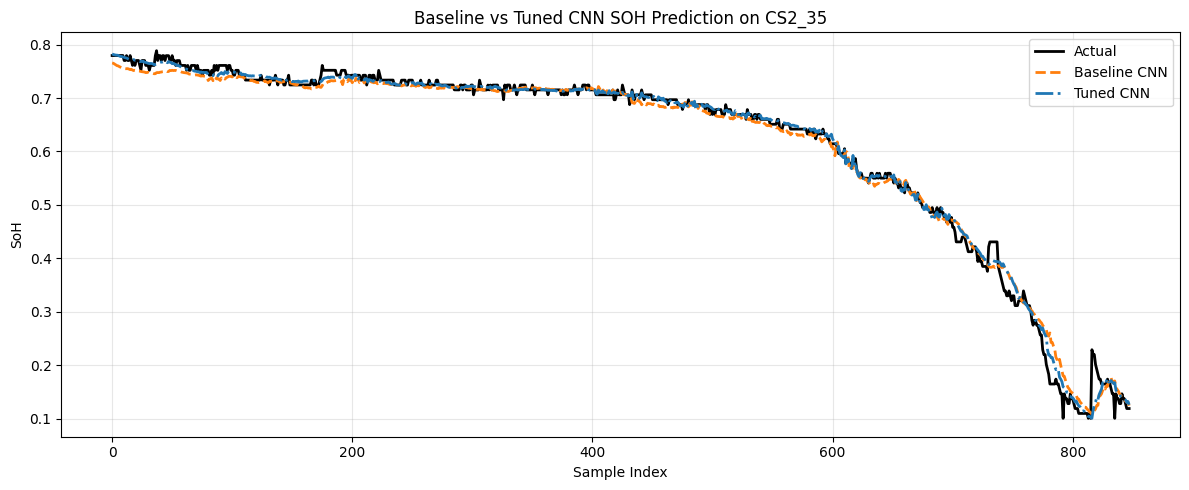

In [ ]:
# Baseline vs tuned CNN prediction curves on the hold-out battery
# Dataset used throughout this notebook: CALCE
required_vars = [
    'y_test_true_base_cnn',
    'y_pred_test_base_cnn',
    'y_test_true_tuned_cnn',
    'y_pred_test_tuned_cnn',
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        'Missing predictions: ' + ', '.join(missing) + '. Run the baseline and tuning cells first.'
    )

n_base = min(len(y_test_true_base_cnn), len(y_pred_test_base_cnn))
n_tuned = min(len(y_test_true_tuned_cnn), len(y_pred_test_tuned_cnn))
n_cmp = min(n_base, n_tuned)

x_axis = np.arange(n_cmp)
y_true_cmp = np.asarray(y_test_true_tuned_cnn[:n_cmp]).ravel()
y_base_cmp = np.asarray(y_pred_test_base_cnn[:n_cmp]).ravel()
y_tuned_cmp = np.asarray(y_pred_test_tuned_cnn[:n_cmp]).ravel()

plt.figure(figsize=(12, 5))
plt.plot(x_axis, y_true_cmp, label='Actual', color='black', linewidth=2)
plt.plot(x_axis, y_base_cmp, label='Baseline CNN', linestyle='--', linewidth=2, color='tab:orange')
plt.plot(x_axis, y_tuned_cmp, label='Tuned CNN', linestyle='-.', linewidth=2, color='tab:blue')
plt.title('Baseline vs Tuned CNN SOH Prediction on CS2_35')
plt.xlabel('Sample Index')
plt.ylabel('SoH')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Baseline vs Tuned CNN (lower is better)
Metric  Baseline    Tuned  Improvement_%
  RMSE  0.018238 0.013521      25.861520
   MAE  0.012157 0.007841      35.503158


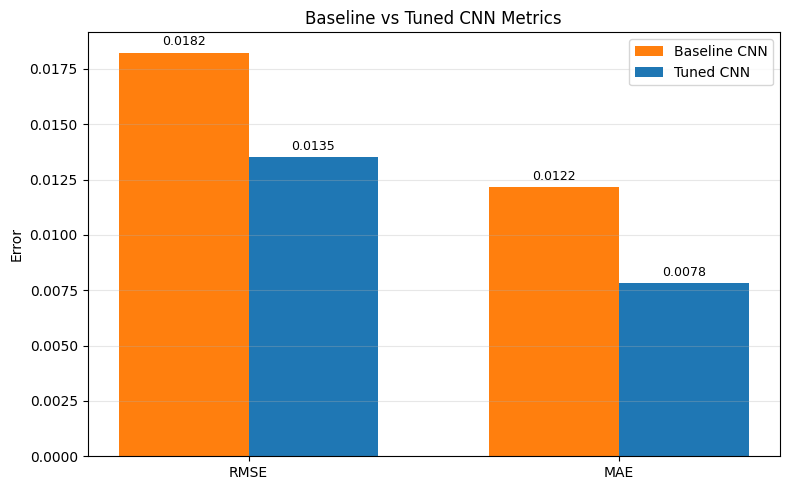


Saved: cnn_baseline_vs_tuned_comparison.csv


In [ ]:
# Baseline vs tuned CNN metric comparison on the hold-out battery
required_metric_vars = ['rmse_cnn', 'mae_cnn', 'rmse_cnn_tuned', 'mae_cnn_tuned']
missing_metric_vars = [v for v in required_metric_vars if v not in globals()]
if missing_metric_vars:
    raise RuntimeError(
        'Missing metrics: ' + ', '.join(missing_metric_vars) + '. Run the baseline and tuning cells first.'
    )

comparison_cnn = pd.DataFrame([
    {'Model': 'Baseline CNN', 'RMSE': float(rmse_cnn), 'MAE': float(mae_cnn)},
    {'Model': 'Tuned CNN', 'RMSE': float(rmse_cnn_tuned), 'MAE': float(mae_cnn_tuned)},
])

baseline_rmse = comparison_cnn.loc[
    comparison_cnn['Model'] == 'Baseline CNN', 'RMSE'
].iloc[0]
baseline_mae = comparison_cnn.loc[
    comparison_cnn['Model'] == 'Baseline CNN', 'MAE'
].iloc[0]
tuned_rmse = comparison_cnn.loc[
    comparison_cnn['Model'] == 'Tuned CNN', 'RMSE'
].iloc[0]
tuned_mae = comparison_cnn.loc[
    comparison_cnn['Model'] == 'Tuned CNN', 'MAE'
].iloc[0]

rmse_improvement_pct = (baseline_rmse - tuned_rmse) / baseline_rmse * 100.0 if baseline_rmse != 0 else np.nan
mae_improvement_pct = (baseline_mae - tuned_mae) / baseline_mae * 100.0 if baseline_mae != 0 else np.nan

summary = pd.DataFrame([
    {
        'Metric': 'RMSE',
        'Baseline': baseline_rmse,
        'Tuned': tuned_rmse,
        'Improvement_%': rmse_improvement_pct,
    },
    {
        'Metric': 'MAE',
        'Baseline': baseline_mae,
        'Tuned': tuned_mae,
        'Improvement_%': mae_improvement_pct,
    }
])

print('Baseline vs Tuned CNN (lower is better)')
print(summary.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['RMSE', 'MAE']
baseline_vals = [baseline_rmse, baseline_mae]
tuned_vals = [tuned_rmse, tuned_mae]
x = np.arange(len(metrics))
width = 0.35

bars_base = ax.bar(x - width / 2, baseline_vals, width, label='Baseline CNN', color='tab:orange')
bars_tuned = ax.bar(x + width / 2, tuned_vals, width, label='Tuned CNN', color='tab:blue')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Error')
ax.set_title('Baseline vs Tuned CNN Metrics')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()

for bar in list(bars_base) + list(bars_tuned):
    height = bar.get_height()
    ax.annotate(
        f'{height:.4f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
plt.show()

summary.to_csv('cnn_baseline_vs_tuned_comparison.csv', index=False)
print('\nSaved: cnn_baseline_vs_tuned_comparison.csv')